## **Library**

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix,classification_report
from sklearn.preprocessing import LabelEncoder

## **Data Understanding & Data Cleaning**

### Load Data

#### Data Training

In [2]:
data_train= pd.read_csv('/content/data_training.csv')
data_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [3]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


Data tersebut merupakan data yang menggambarkan kualitas wine berdasarkan berbagai karakteristik kimia yang terkandung di dalamnya. Pada penelitian ini, variabel **quality** digunakan sebagai **target (label)**, sedangkan fitur lainnya digunakan sebagai variabel prediktor. Model machine learning dibangun untuk mempelajari hubungan antara karakteristik kimia wine dengan tingkat kualitasnya, sehingga dapat digunakan untuk memprediksi kualitas wine berdasarkan fitur-fitur tersebut.<br>

Fitur-fitur tersebut antara lain:

- Fixed Acidity: Menunjukkan tingkat keasaman tetap dalam wine yang berasal dari asam organik yang tidak mudah menguap.
- Volatile Acidity: Menggambarkan kadar asam yang mudah menguap, yang dapat memengaruhi aroma wine.
- Citric Acid: Kandungan asam sitrat yang berkontribusi pada kesegaran dan rasa wine.
- Residual Sugar: Jumlah gula yang tersisa setelah proses fermentasi, yang memengaruhi tingkat kemanisan.
- Chlorides: Kadar garam dalam wine yang dapat memengaruhi cita rasa.
- Free Sulfur Dioxide: Jumlah sulfur dioksida bebas yang berfungsi sebagai pengawet.
- Total Sulfur Dioxide: Total keseluruhan sulfur dioksida dalam wine, baik yang bebas maupun terikat.
- Density: Kepadatan wine yang berkaitan dengan kandungan gula dan alkohol.
- pH: Tingkat keasaman wine dalam skala pH.
- Sulphates: Senyawa yang berperan dalam stabilitas dan dapat memengaruhi kualitas rasa.
- Alcohol: Persentase kandungan alkohol dalam wine.
- Id: Identitas unik setiap data yang tidak digunakan dalam proses analisis atau pemodelan.

#### Data Testing

In [4]:
data_test= pd.read_csv('/content/data_testing.csv')
data_test.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


In [5]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         286 non-null    float64
 1   volatile acidity      286 non-null    float64
 2   citric acid           286 non-null    float64
 3   residual sugar        286 non-null    float64
 4   chlorides             286 non-null    float64
 5   free sulfur dioxide   286 non-null    float64
 6   total sulfur dioxide  286 non-null    float64
 7   density               286 non-null    float64
 8   pH                    286 non-null    float64
 9   sulphates             286 non-null    float64
 10  alcohol               286 non-null    float64
 11  Id                    286 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 26.9 KB


In [6]:
data_train = data_train.drop(columns=['Id'])

Kolom Id dihapus dari data training karena hanya berfungsi sebagai identitas unik setiap data dan tidak memiliki pengaruh terhadap proses pemodelan machine learning.

In [7]:
data_train.shape

(857, 12)

Dataset terdiri dari 857 baris yang merepresentasikan jumlah sampel wine dan 12 kolom yang merupakan variabel atau fitur yang digunakan dalam analisis.

### Missing Value

#### Data Training

In [8]:
data_train.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Seluruh variabel dalam dataset tidak memiliki nilai yang hilang (missing value).

#### Data Testing

In [9]:
data_test.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Seluruh variabel dalam dataset tidak memiliki nilai yang hilang (missing value).

### Data Duplikat

#### Data Training

In [10]:
data_train.duplicated().sum()

np.int64(76)

Terdapat 76 data duplikat dalam dataset.

In [11]:
data_train = data_train.drop_duplicates()

In [12]:
data_train.duplicated().sum()

np.int64(0)

In [13]:
data_train.shape

(781, 12)

Data duplikat telah dihapus sehingga tidak terdapat lagi data yang terduplikasi, dan jumlah data akhir menjadi 781 baris.

#### Data Test

In [14]:
data_test.duplicated().sum()

np.int64(0)

Tidak terdapat duplikat dalam dataset.

### Statistika Deskriptif

In [15]:
data_train.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,781.000000,781.000000,781.000000,781.000000,781.000000,781.000000,781.000000,781.000000,781.000000,781.000000,781.000000,781.000000
mean,8.243278,0.531671,0.268054,2.517990,0.087382,15.772087,46.313060,0.996674,3.313342,0.656837,10.444814,5.642766
std,1.703216,0.181842,0.195780,1.273459,0.050592,10.289772,31.973601,0.001910,0.154097,0.168354,1.084940,0.826897
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000
25%,7.100000,0.400000,0.090000,1.900000,0.069000,7.000000,21.000000,0.995540,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,39.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.000000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.720000,11.200000,6.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000


Berdasarkan hasil statistika deskriptif, diperoleh gambaran umum dari masing-masing variabel sebagai berikut:
- Fixed Acidity<br>
Variabel fixed acidity memiliki nilai rata-rata sebesar 8.24 dengan median sebesar 7.9 serta rentang nilai antara 4.6 hingga 15.6. Sebagian besar data berada pada kisaran 7.1 hingga 9.1. Distribusi variabel ini cenderung bersifat right skewed (miring ke kanan), yang ditunjukkan oleh nilai rata-rata yang lebih besar dibandingkan median serta adanya nilai maksimum yang cukup jauh dari kuartil atas.
- Volatile Acidity<br>
Variabel volatile acidity memiliki rata-rata sebesar 0.53 dengan median 0.52 dan rentang nilai antara 0.12 hingga 1.58. Sebagian besar data berada pada kisaran 0.4 hingga 0.64. Meskipun nilai rata-rata dan median relatif berdekatan, terdapat nilai maksimum yang cukup tinggi sehingga distribusi cenderung sedikit right skewed.
- Citric Acid<br>
Variabel citric acid memiliki rata-rata sebesar 0.27 dengan median 0.25 dan rentang nilai antara 0 hingga 1. Sebagian besar data berada pada kisaran 0.09 hingga 0.42. Distribusi data relatif cukup seimbang, meskipun terdapat sedikit indikasi kemiringan ke kanan.
- Residual Sugar<br>
Variabel residual sugar memiliki rata-rata sebesar 2.51 dengan median 2.2 dan rentang nilai antara 0.9 hingga 15.5. Sebagian besar data terkonsentrasi pada kisaran 1.9 hingga 2.6. Nilai maksimum yang jauh lebih tinggi menunjukkan distribusi yang right skewed dengan indikasi adanya outlier.
- Chlorides<br>
Variabel chlorides memiliki rata-rata sebesar 0.087 dengan median 0.079 dan rentang nilai antara 0.012 hingga 0.611. Sebagian besar data berada pada kisaran 0.07 hingga 0.09. Distribusi menunjukkan right skewed akibat adanya nilai maksimum yang cukup tinggi.
- Free Sulfur Dioxide<br>
Variabel free sulfur dioxide memiliki rata-rata sebesar 15.78 dengan median 14 dan rentang nilai antara 1 hingga 68. Sebagian besar data berada pada kisaran 7 hingga 21. Distribusi cenderung sedikit right skewed.
- Total Sulfur Dioxide<br>
Variabel total sulfur dioxide memiliki rata-rata sebesar 46.31 dengan median 39 dan rentang nilai antara 6 hingga 278. Sebagian besar data berada pada kisaran 21 hingga 63. Rentang yang sangat lebar menunjukkan distribusi yang right skewed dengan kemungkinan outlier.
- Density<br>
Variabel density memiliki rata-rata sebesar 0.9967 dengan median 0.99668 dan rentang nilai antara 0.99007 hingga 1.0032. Variasi data relatif kecil dan nilai rata-rata hampir sama dengan median, sehingga distribusi cenderung simetris.
- pH<br>
Variabel pH memiliki rata-rata sebesar 3.31 dengan median 3.31 dan rentang nilai antara 2.74 hingga 4.01. Sebagian besar data berada pada kisaran 3.21 hingga 3.40. Distribusi variabel ini cenderung simetris.
- Sulphates<br>
Variabel sulphates memiliki rata-rata sebesar 0.65 dengan median 0.62 dan rentang nilai antara 0.39 hingga 2. Sebagian besar data berada pada kisaran 0.55 hingga 0.72. Nilai maksimum yang cukup tinggi menunjukkan distribusi right skewed.
- Alcohol<br>
Variabel alcohol memiliki rata-rata sebesar 10.44 dengan median 10.2 dan rentang nilai antara 8.4 hingga 14. Sebagian besar data berada pada kisaran 9.5 hingga 11.2. Distribusi cenderung sedikit right skewed.



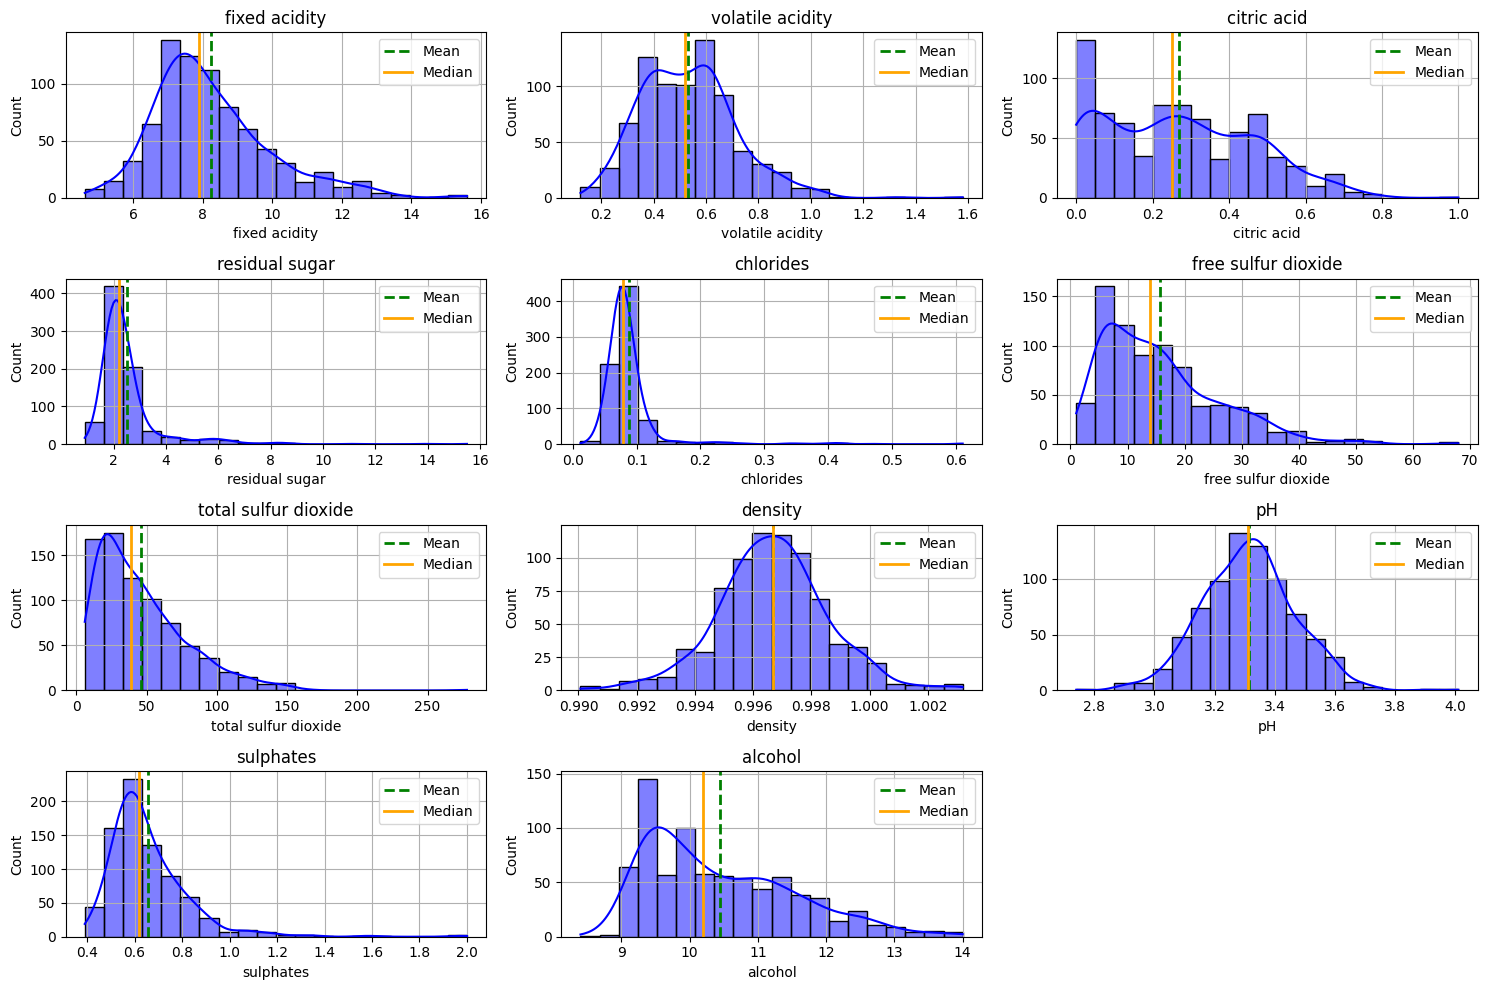

In [16]:
data_num = data_train.drop(columns=['quality'])

cols = data_num.columns
n_cols = 3
n_rows = (len(cols) // n_cols) + 1

plt.figure(figsize=(15,10))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)

    # Histogram + KDE (warna beda)
    sns.histplot(
        data_num[col],
        bins=20,
        kde=True,
        color='blue',          # warna histogram
        line_kws={'color': 'red'} # warna garis KDE
    )

    # Mean & Median
    mean = data_num[col].mean()
    median = data_num[col].median()

    # Garis vertikal dengan warna beda
    plt.axvline(mean, color='green', linestyle='--', linewidth=2, label='Mean')
    plt.axvline(median, color='orange', linestyle='-', linewidth=2, label='Median')

    plt.title(col)
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

Berdasarkan visualisasi histogram, diperoleh gambaran distribusi masing-masing variabel sebagai berikut:

- Fixed Acidity<br>
Distribusi variabel fixed acidity terlihat relatif mendekati simetris, namun sedikit cenderung right skewed dengan adanya ekor di sisi kanan.
- Volatile Acidity<br>
Variabel volatile acidity menunjukkan distribusi yang cukup mendekati normal, meskipun terdapat sedikit kemiringan ke kanan.
- Citric Acid<br>
Distribusi citric acid cenderung right skewed, dengan banyak nilai rendah mendekati 0 dan frekuensi yang semakin menurun pada nilai yang lebih tinggi.
- Residual Sugar<br>
Variabel residual sugar menunjukkan distribusi yang sangat right skewed, dengan sebagian besar data berada pada nilai rendah dan terdapat ekor panjang ke arah kanan yang mengindikasikan adanya nilai ekstrem (outlier).
- Chlorides<br>
Distribusi chlorides juga right skewed, dengan mayoritas nilai kecil dan beberapa nilai tinggi yang cukup jauh dari pusat distribusi.
- Free Sulfur Dioxide<br>
Variabel free sulfur dioxide memiliki distribusi yang right skewed, dengan sebagian besar data berada pada nilai rendah hingga menengah, serta ekor ke arah nilai yang lebih tinggi.
- Total Sulfur Dioxide<br>
Distribusi total sulfur dioxide sangat right skewed, ditandai dengan ekor panjang ke kanan dan adanya nilai yang cukup ekstrem.
- Density<br>
Variabel density menunjukkan distribusi yang mendekati normal (simetris), dengan data terkonsentrasi di sekitar nilai tengah dan tidak menunjukkan kemiringan yang signifikan.
- pH<br>
Distribusi pH juga terlihat simetris dan mendekati normal, dengan sebagian besar data berada di sekitar nilai tengah tanpa adanya outlier ekstrem.
- Sulphates<br>
Variabel sulphates menunjukkan distribusi right skewed, dengan mayoritas data pada nilai rendah dan beberapa nilai tinggi yang membentuk ekor kanan.
- Alcohol<br>
Distribusi alcohol cenderung sedikit right skewed, dengan sebagian besar data berada pada kisaran menengah dan terdapat beberapa nilai tinggi.

### Headmap

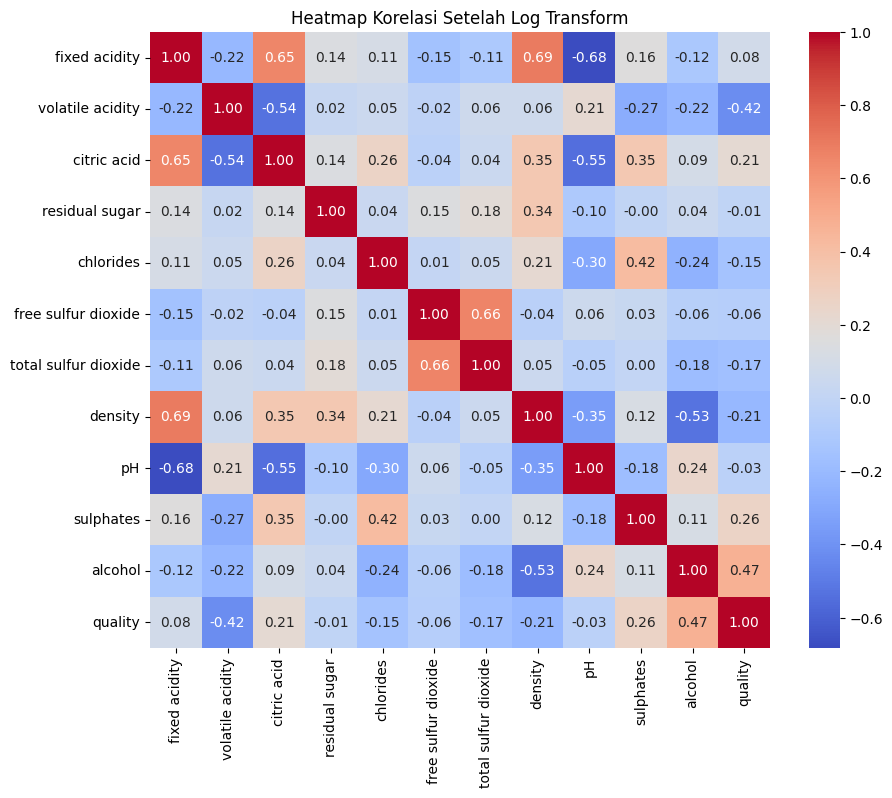

In [17]:
plt.figure(figsize=(10, 8))

corr = data_train.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Heatmap Korelasi Setelah Log Transform")
plt.show()

Berdasarkan heatmap korelasi, variabel yang memiliki hubungan paling kuat dengan **quality** adalah **alcohol** dengan korelasi positif sebesar 0,47 dan **volatile acidity** dengan korelasi negatif sebesar -0,42. Hal ini menunjukkan bahwa peningkatan kadar alkohol cenderung meningkatkan kualitas, sedangkan tingginya volatile acidity berhubungan dengan penurunan kualitas.<br>


Variabel lain seperti **sulphates** (0,26) dan **citric acid** (0,21) juga memiliki korelasi positif terhadap kualitas, namun dalam kategori lemah hingga sedang. Sementara itu, sebagian besar fitur lainnya menunjukkan korelasi yang rendah terhadap quality, sehingga pengaruhnya terhadap model cenderung tidak signifikan secara individual.<br>


Selain itu, terdapat korelasi yang cukup tinggi antar beberapa fitur, seperti **free sulfur dioxide** dan **total sulfur dioxide** (0,66). Variabel **fixed acidity** juga menunjukkan korelasi yang cukup kuat dengan beberapa fitur lain, seperti **citric acid** (0,65), **density** (0,69), dan **pH** (-0,68). Hal ini mengindikasikan adanya potensi multikolinearitas dalam dataset.

### Feature Selection

In [18]:
data_train = data_train.drop(columns=['free sulfur dioxide'])

In [19]:
data_test=data_test.drop(columns=['free sulfur dioxide'])

Dilakukan penghapusan pada fitur free sulfur dioxide karena memiliki korelasi yang cukup tinggi dengan total sulfur dioxide (0,66), sehingga keduanya dianggap merepresentasikan informasi yang serupa (redundan). Oleh karena itu, dipilih salah satu fitur yang lebih representatif, yaitu total sulfur dioxide.<br>

Sementara itu, pada fitur fixed acidity, citric acid, density, dan pH, meskipun terdapat korelasi yang cukup kuat, fitur-fitur tersebut tidak dihapus. Hal ini karena masing-masing variabel masih merepresentasikan aspek yang berbeda dari karakteristik kimia wine dan berpotensi memberikan informasi tambahan yang relevan terhadap target. Dengan demikian, fitur-fitur tersebut tetap dipertahankan dalam proses pemodelan.

### Outlier

In [20]:
#  Hitung IQR
Q1 = data_train.quantile(0.25)
Q3 = data_train.quantile(0.75)
IQR = Q3 - Q1

# Deteksi outlier
outliers = (data_train < (Q1 - 1.5 * IQR)) | (data_train > (Q3 + 1.5 * IQR))

# Jumlah outlier per kolom
outlier_count = outliers.sum()
print("Jumlah outlier per fitur:")
print(outlier_count)

# Total baris yang mengandung outlier

outlier_rows = data_train[outliers.any(axis=1)]
print("\nJumlah baris yang mengandung outlier:", outlier_rows.shape[0])



Jumlah outlier per fitur:
fixed acidity           35
volatile acidity         9
citric acid              1
residual sugar          71
chlorides               47
total sulfur dioxide    18
density                 23
pH                      13
sulphates               30
alcohol                  4
quality                 18
dtype: int64

Jumlah baris yang mengandung outlier: 194


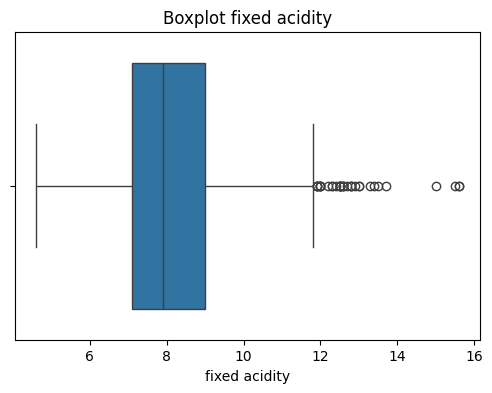

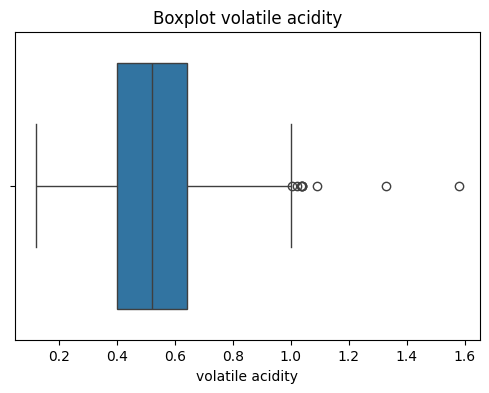

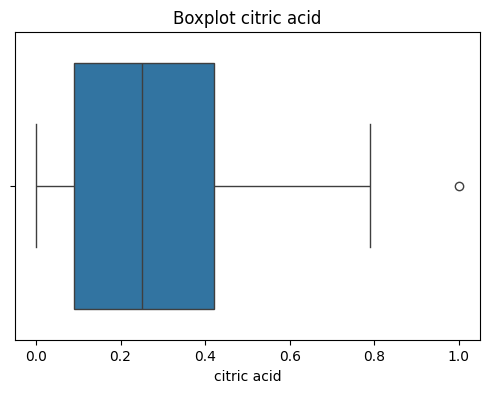

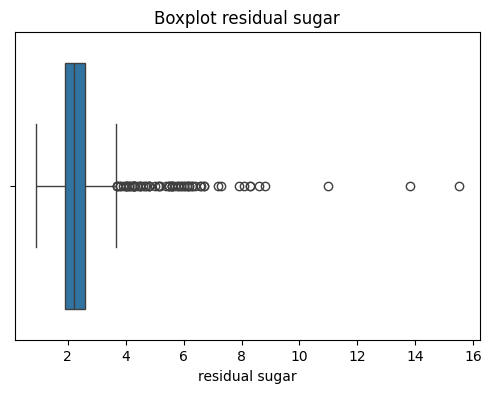

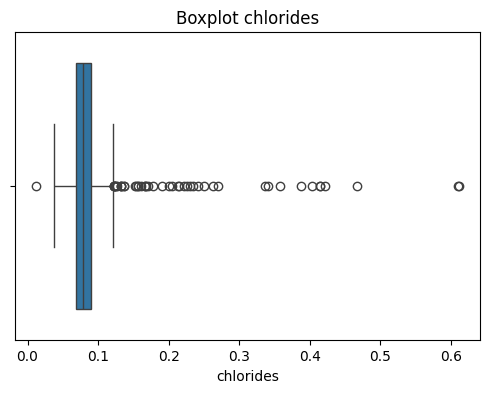

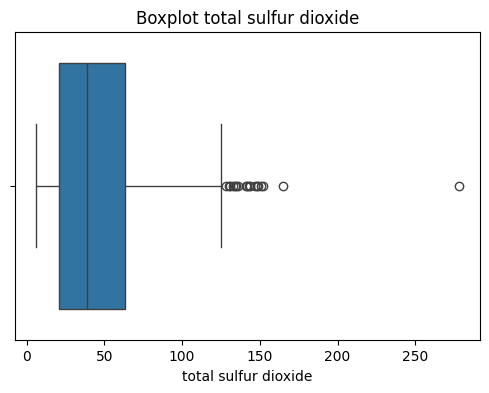

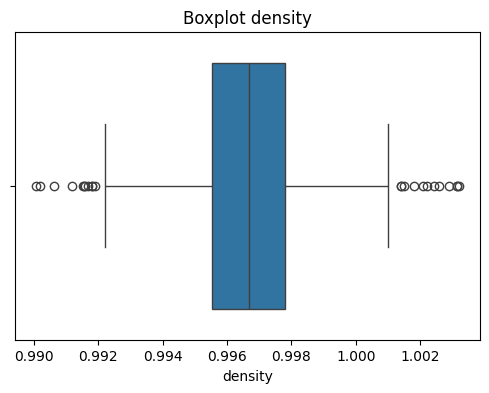

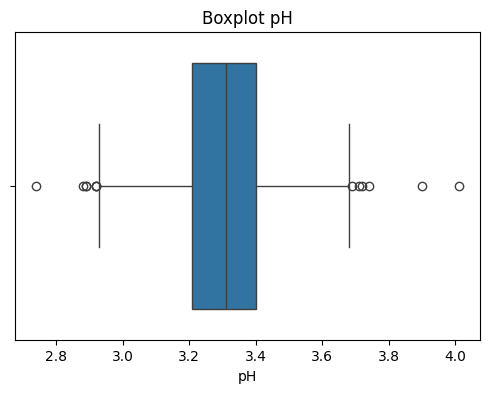

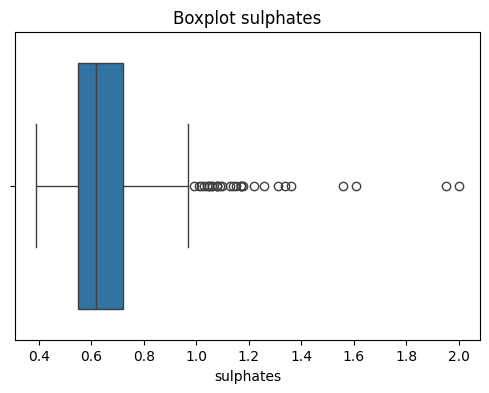

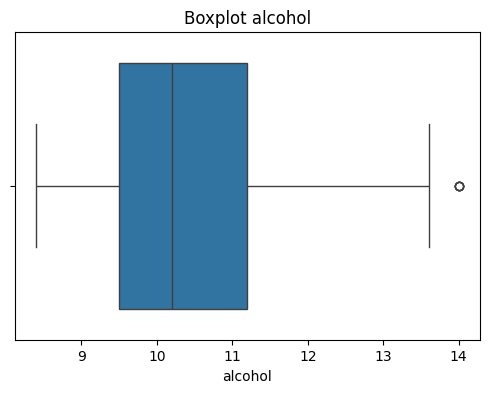

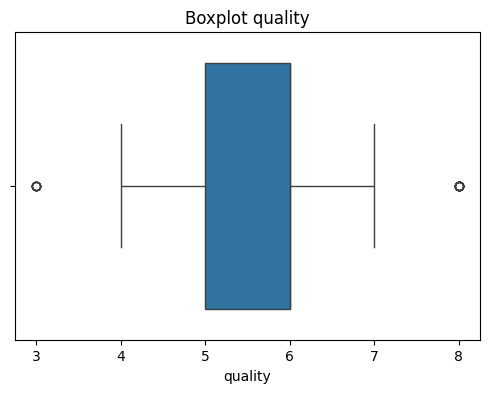

In [21]:
# Loop tiap kolom
for col in data_train.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data_train[col])
    plt.title(f'Boxplot {col}')
    plt.xlabel(col)
    plt.show()

### Imbalance

In [22]:
class_dist = pd.DataFrame({
    'Jumlah': data_train['quality'].value_counts(),
    'Persentase (%)': data_train['quality'].value_counts(normalize=True) * 100
})

print(class_dist.sort_index())

         Jumlah  Persentase (%)
quality                        
3             6        0.768246
4            26        3.329065
5           330       42.253521
6           310       39.692702
7            97       12.419974
8            12        1.536492


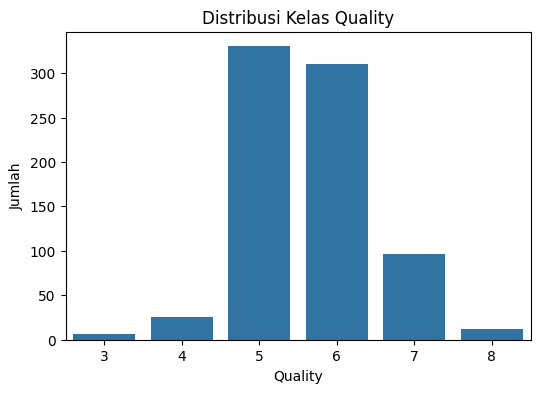

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x=data_train['quality'])
plt.title("Distribusi Kelas Quality")
plt.xlabel("Quality")
plt.ylabel("Jumlah")
plt.show()

Berdasarkan distribusi data, terlihat bahwa jumlah data pada setiap kelas quality tidak seimbang, di mana kelas 5 dan 6 mendominasi dataset, sedangkan kelas lainnya memiliki jumlah yang jauh lebih sedikit.

## **Modeling & Evaluasi**

### Data Splitting

In [24]:
le = LabelEncoder()
y = le.fit_transform(data_train['quality'])

X = data_train.drop(columns=['quality'])

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
# Lihat hasil encoding
mapping = pd.DataFrame({
    'Label Asli': le.classes_,
    'Hasil Encode': range(len(le.classes_))
})

print(mapping)

   Label Asli  Hasil Encode
0           3             0
1           4             1
2           5             2
3           6             3
4           7             4
5           8             5


In [26]:
# ubah ke series
y_train = pd.Series(y_train)
y_test = pd.Series(y_test)

# Jumlah data
print("=== JUMLAH DATA ===")
print(f"Train: {X_train.shape[0]} baris")
print(f"Test : {X_test.shape[0]} baris")

# Distribusi kelas
train_dist = pd.DataFrame({
    'Jumlah': y_train.value_counts(),
    'Persentase (%)': y_train.value_counts(normalize=True) * 100
})

test_dist = pd.DataFrame({
    'Jumlah': y_test.value_counts(),
    'Persentase (%)': y_test.value_counts(normalize=True) * 100
})

print("\n=== DISTRIBUSI KELAS TRAIN ===")
print(train_dist)

print("\n=== DISTRIBUSI KELAS TEST ===")
print(test_dist)

=== JUMLAH DATA ===
Train: 624 baris
Test : 157 baris

=== DISTRIBUSI KELAS TRAIN ===
   Jumlah  Persentase (%)
2     264       42.307692
3     248       39.743590
4      77       12.339744
1      21        3.365385
5       9        1.442308
0       5        0.801282

=== DISTRIBUSI KELAS TEST ===
   Jumlah  Persentase (%)
2      66       42.038217
3      62       39.490446
4      20       12.738854
1       5        3.184713
5       3        1.910828
0       1        0.636943


In [27]:
test_id = data_test['Id']

X_submit = data_test.drop(columns=['Id'])

### Scaling

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_submit_scaled = scaler.transform(X_submit)

### Data Asli

In [30]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.6 MB/s eta 0:00:00


In [29]:
from catboost import CatBoostClassifier

In [30]:
# MODEL
models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ),

    "Naive Bayes": GaussianNB(),

    "XGBoost": XGBClassifier(
        eval_metric='mlogloss',
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        class_weight='balanced'
    ),

    "CatBoost": CatBoostClassifier(
        random_state=42,
        verbose=0
    )
}

results = []


# TRAINING & EVALUASI
for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Prediksi
    y_pred = model.predict(X_test)


    # METRICS
    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    # Weighted
    prec_weighted = precision_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    rec_weighted = recall_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    f1_weighted = f1_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    # Macro
    prec_macro = precision_score(
        y_test,
        y_pred,
        average='macro',
        zero_division=0
    )

    rec_macro = recall_score(
        y_test,
        y_pred,
        average='macro',
        zero_division=0
    )

    f1_macro = f1_score(
        y_test,
        y_pred,
        average='macro',
        zero_division=0
    )

    # Simpan hasil
    results.append({
        "Model": name,

        "Accuracy": acc,

        "Precision Weighted": prec_weighted,
        "Recall Weighted": rec_weighted,
        "F1 Weighted": f1_weighted,

        "Precision Macro": prec_macro,
        "Recall Macro": rec_macro,
        "F1 Macro": f1_macro
    })


# HASIL
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Macro",
    ascending=False
)

print(results_df)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000170 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 796
[LightGBM] [Info] Number of data points in the train set: 624, number of used features: 10
[LightGBM] [Info] Start training from score -1.791760
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

### Random Over Sampler

In [32]:
from imblearn.over_sampling import RandomOverSampler

In [35]:
# RANDOM OVERSAMPLER
ros = RandomOverSampler(
    sampling_strategy={
        0: 40,
        1: 40,
        4: 100,
        5: 40
    },
    random_state=42
)

X_train_ros, y_train_ros = ros.fit_resample(
    X_train,
    y_train
)

# Cek distribusi setelah balancing
print("=== DISTRIBUSI SETELAH ROS ===")
print(pd.Series(y_train_ros).value_counts())

# MODEL
models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ),

    "Naive Bayes": GaussianNB(),

    "XGBoost": XGBClassifier(
        eval_metric='mlogloss',
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        class_weight='balanced'
    ),

    "CatBoost": CatBoostClassifier(
        random_state=42,
        verbose=0
    )
}

results = []

# TRAINING & EVALUASI
for name, model in models.items():

    print(f"\n===== {name} =====")

    # Train pakai data ROS
    model.fit(X_train_ros, y_train_ros)

    # Prediksi data test asli
    y_pred = model.predict(X_test)


    # METRICS
    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    # Weighted
    prec_weighted = precision_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    rec_weighted = recall_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    f1_weighted = f1_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    # Macro
    prec_macro = precision_score(
        y_test,
        y_pred,
        average='macro',
        zero_division=0
    )

    rec_macro = recall_score(
        y_test,
        y_pred,
        average='macro',
        zero_division=0
    )

    f1_macro = f1_score(
        y_test,
        y_pred,
        average='macro',
        zero_division=0
    )

    # Simpan hasil
    results.append({
        "Model": name,

        "Accuracy": acc,

        "Precision Weighted": prec_weighted,
        "Recall Weighted": rec_weighted,
        "F1 Weighted": f1_weighted,

        "Precision Macro": prec_macro,
        "Recall Macro": rec_macro,
        "F1 Macro": f1_macro
    })

    # Classification report
    print(classification_report(y_test, y_pred))


# HASIL AKHIR
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Macro",
    ascending=False
)

print("\n=== HASIL SEMUA MODEL ===")
print(results_df)

=== DISTRIBUSI SETELAH ROS ===
2    264
3    248
4    100
1     40
5     40
0     40
Name: count, dtype: int64

===== Decision Tree =====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         5
           2       0.63      0.70      0.66        66
           3       0.53      0.52      0.52        62
           4       0.47      0.45      0.46        20
           5       0.00      0.00      0.00         3

    accuracy                           0.55       157
   macro avg       0.27      0.28      0.27       157
weighted avg       0.54      0.55      0.54       157


===== Random Forest =====


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         5
           2       0.63      0.76      0.69        66
           3       0.56      0.60      0.58        62
           4       0.64      0.35      0.45        20
           5       0.00      0.00      0.00         3

    accuracy                           0.60       157
   macro avg       0.30      0.28      0.29       157
weighted avg       0.57      0.60      0.58       157


===== Naive Bayes =====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.18      0.60      0.27         5
           2       0.63      0.55      0.59        66
           3       0.50      0.44      0.47        62
           4       0.33      0.15      0.21        20
           5       0.12      0.67      0.20         3

    accuracy                           0.45       15

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         5
           2       0.65      0.77      0.71        66
           3       0.57      0.53      0.55        62
           4       0.47      0.40      0.43        20
           5       0.00      0.00      0.00         3

    accuracy                           0.59       157
   macro avg       0.28      0.28      0.28       157
weighted avg       0.56      0.59      0.57       157


===== LightGBM =====
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000193 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 835
[LightGBM] [Info] Number of data points in the train set: 732, number of used features: 10
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Inf

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         5
           2       0.62      0.68      0.65        66
           3       0.50      0.45      0.47        62
           4       0.35      0.40      0.37        20
           5       0.00      0.00      0.00         3

    accuracy                           0.52       157
   macro avg       0.24      0.26      0.25       157
weighted avg       0.50      0.52      0.51       157


===== CatBoost =====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         5
           2       0.63      0.77      0.69        66
           3       0.55      0.52      0.53        62
           4       0.50      0.40      0.44        20
           5       0.00      0.00      0.00         3

    accuracy                           0.58       157
 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### SMOTE

In [37]:
from imblearn.over_sampling import SMOTE

In [38]:
# =========================
# SMOTE
# =========================
smote = SMOTE(
    sampling_strategy={
        0: 40,
        1: 40,
        4: 100,
        5: 40
    },
    random_state=42,
    k_neighbors=2
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Cek distribusi setelah SMOTE
print("=== DISTRIBUSI SETELAH SMOTE ===")
print(pd.Series(y_train_smote).value_counts())

# =========================
# MODEL
# =========================
models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ),

    "Naive Bayes": GaussianNB(),

    "XGBoost": XGBClassifier(
        eval_metric='mlogloss',
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        class_weight='balanced'
    ),

    "CatBoost": CatBoostClassifier(
        random_state=42,
        verbose=0
    )
}

results = []

# =========================
# TRAINING & EVALUASI
# =========================
for name, model in models.items():

    print(f"\n===== {name} =====")

    # Train pakai data SMOTE
    model.fit(X_train_smote, y_train_smote)

    # Prediksi data test asli
    y_pred = model.predict(X_test)

    # =========================
    # METRICS
    # =========================

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    # Weighted
    prec_weighted = precision_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    rec_weighted = recall_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    f1_weighted = f1_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    # Macro
    prec_macro = precision_score(
        y_test,
        y_pred,
        average='macro',
        zero_division=0
    )

    rec_macro = recall_score(
        y_test,
        y_pred,
        average='macro',
        zero_division=0
    )

    f1_macro = f1_score(
        y_test,
        y_pred,
        average='macro',
        zero_division=0
    )

    # Simpan hasil
    results.append({
        "Model": name,

        "Accuracy": acc,

        "Precision Weighted": prec_weighted,
        "Recall Weighted": rec_weighted,
        "F1 Weighted": f1_weighted,

        "Precision Macro": prec_macro,
        "Recall Macro": rec_macro,
        "F1 Macro": f1_macro
    })

    # Classification report
    print(classification_report(y_test, y_pred))

# =========================
# HASIL AKHIR
# =========================
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Macro",
    ascending=False
)

print("\n=== HASIL SEMUA MODEL ===")
print(results_df)

=== DISTRIBUSI SETELAH SMOTE ===
2    264
3    248
4    100
1     40
5     40
0     40
Name: count, dtype: int64

===== Decision Tree =====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         5
           2       0.57      0.62      0.59        66
           3       0.49      0.39      0.43        62
           4       0.52      0.55      0.54        20
           5       0.00      0.00      0.00         3

    accuracy                           0.48       157
   macro avg       0.26      0.26      0.26       157
weighted avg       0.50      0.48      0.49       157


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         5
           2       0.65      0.74      0.70        66
           3       0.56      0.56      0.56        62
           4       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         5
           2       0.64      0.74      0.69        66
           3       0.54      0.48      0.51        62
           4       0.37      0.35      0.36        20
           5       0.00      0.00      0.00         3

    accuracy                           0.55       157
   macro avg       0.26      0.26      0.26       157
weighted avg       0.53      0.55      0.53       157


===== CatBoost =====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         5
           2       0.64      0.74      0.69        66
           3       0.57      0.53      0.55        62
           4       0.50      0.40      0.44        20
           5       1.00      0.33      0.50         3

    accuracy                           0.58       157
 

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [40]:
# =========================
# PARAMETER GRID
# =========================
param_grid = {
    'n_estimators': [100, 200, 300],

    'max_depth': [10, 15, 20],

    'min_samples_split': [2, 5],

    'min_samples_leaf': [1, 2],

    'max_features': ['sqrt']
}

# =========================
# MODEL DASAR (tanpa class_weight karena sudah SMOTE)
# =========================
rf = RandomForestClassifier(
    random_state=42
)

# =========================
# GRID SEARCH
# =========================
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,

    scoring='f1_macro',   # lebih adil untuk imbalance

    cv=3,

    n_jobs=-1,

    verbose=2
)

# Train pakai data SMOTE
grid_search.fit(X_train_smote, y_train_smote)

# =========================
# HASIL TERBAIK
# =========================
print("\n=== BEST PARAMETERS ===")
print(grid_search.best_params_)

print("\n=== BEST CV SCORE (F1 Macro) ===")
print(grid_search.best_score_)

# =========================
# MODEL TERBAIK
# =========================
best_rf = grid_search.best_estimator_

# =========================
# PREDIKSI
# =========================
y_pred = best_rf.predict(X_test)

# =========================
# EVALUASI
# =========================

acc = accuracy_score(y_test, y_pred)

prec_weighted = precision_score(
    y_test, y_pred,
    average='weighted',
    zero_division=0
)

rec_weighted = recall_score(
    y_test, y_pred,
    average='weighted',
    zero_division=0
)

f1_weighted = f1_score(
    y_test, y_pred,
    average='weighted',
    zero_division=0
)

prec_macro = precision_score(
    y_test, y_pred,
    average='macro',
    zero_division=0
)

rec_macro = recall_score(
    y_test, y_pred,
    average='macro',
    zero_division=0
)

f1_macro = f1_score(
    y_test, y_pred,
    average='macro',
    zero_division=0
)

# =========================
# HASIL METRICS
# =========================
hasil_eval = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision Weighted',
        'Recall Weighted',
        'F1 Weighted',
        'Precision Macro',
        'Recall Macro',
        'F1 Macro'
    ],
    'Score': [
        acc,
        prec_weighted,
        rec_weighted,
        f1_weighted,
        prec_macro,
        rec_macro,
        f1_macro
    ]
})

print("\n=== HASIL EVALUASI TEST SET ===")
print(hasil_eval)

# =========================
# CLASSIFICATION REPORT
# =========================
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

# =========================
# CONFUSION MATRIX
# =========================
print("\n=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))

Fitting 3 folds for each of 36 candidates, totalling 108 fits

=== BEST PARAMETERS ===
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

=== BEST CV SCORE (F1 Macro) ===
0.6452023975417318

=== HASIL EVALUASI TEST SET ===
               Metric     Score
0            Accuracy  0.566879
1  Precision Weighted  0.541649
2     Recall Weighted  0.566879
3         F1 Weighted  0.552056
4     Precision Macro  0.274887
5        Recall Macro  0.276426
6            F1 Macro  0.274445

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         5
           2       0.64      0.74      0.69        66
           3       0.54      0.52      0.53        62
           4       0.47      0.40      0.43        20
           5       0.00      0.00      0.00         3

    accuracy                           0.57       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model terbaik yang dipilih adalah CatBoostClassifier yang dilatih menggunakan data asli tanpa teknik resampling. Meskipun metode SMOTE dan hyperparameter tuning dapat meningkatkan performa pada data training, model tersebut tidak menunjukkan peningkatan yang konsisten pada data test. CatBoost dipilih karena memberikan performa paling stabil dan tertinggi pada evaluasi data asli, terutama pada accuracy dan F1 weighted, sehingga lebih aman digunakan untuk generalisasi data baru.

In [41]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    random_state=42,
    verbose=0
)

cat_model.fit(X_train, y_train)

CatBoostClassifier(random_state=42, verbose=0)

In [42]:
y_submit_pred = cat_model.predict(X_submit_scaled)

In [43]:
y_submit_label = le.inverse_transform(y_submit_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [44]:
submission = pd.DataFrame({
    "Id": test_id,
    "quality": y_submit_label
})

submission.to_csv("hasilprediksi_009.csv", index=False)